# 아리마

In [1]:
import os
import pandas as pd
import numpy as np
from plt_rcs import *
import hds

In [2]:
plt.rc(group='figure', figsize=(12, 4))

In [3]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/time_series'

In [4]:
os.chdir('../../data')

In [5]:
[i for i in os.listdir() if 'Bike' in i]

['Seoul_Bike_Prep.pkl', 'Seoul_Bike_Daily_2021_2025.csv']

In [6]:
objs = pd.read_pickle('Seoul_Bike_Prep.pkl')

In [7]:
globals().update(objs)

In [8]:
%whos

Variable   Type         Data/Info
---------------------------------
df         DataFrame    Shape: (1820, 1)
hds        module       <module 'hds' from '/opt/<...>ackages/hds/__init__.py'>
np         module       <module 'numpy' from '/op<...>kages/numpy/__init__.py'>
objs       dict         n=3
os         module       <module 'os' (frozen)>
pd         module       <module 'pandas' from '/o<...>ages/pandas/__init__.py'>
plt        module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns        module       <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
test       DataFrame    Shape: (365, 1)
train      DataFrame    Shape: (1461, 1)


In [9]:
test, train, df = test, train, df

## 차분 전 데이터로 ACF, PACF 플롯 시각화

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

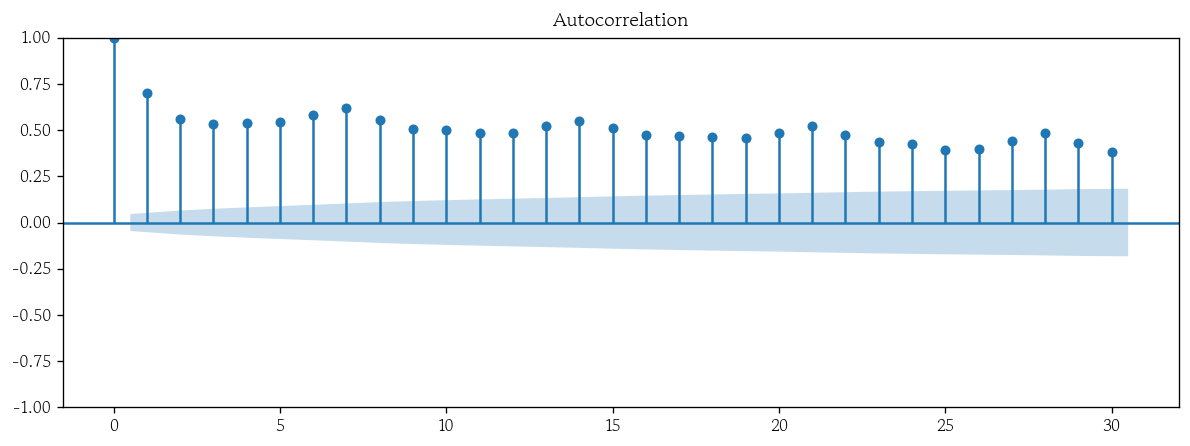

In [11]:
plot_acf(x=df, lags=30);

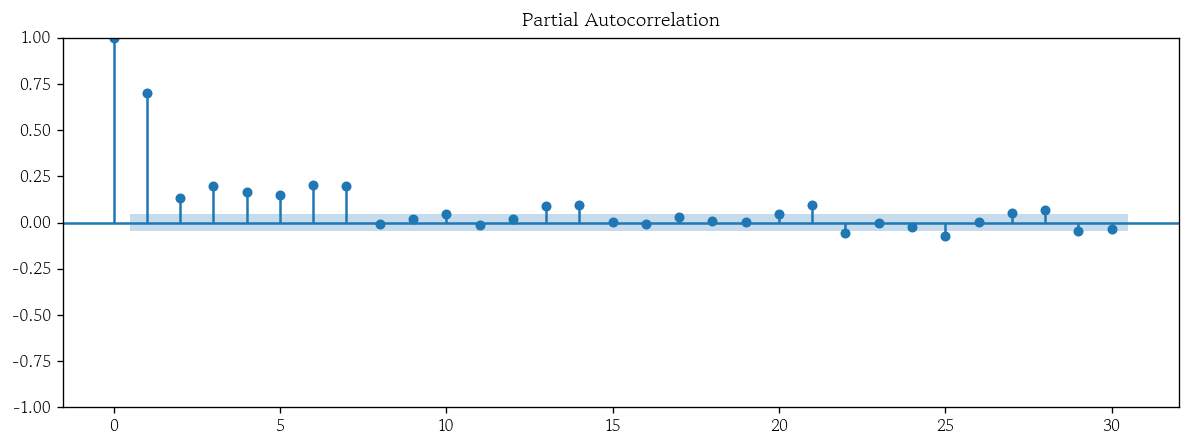

In [12]:
plot_pacf(x=df, lags=30);

## 1차 차분 데이터

In [13]:
use_diff_1 = df.diff(1).dropna()

In [14]:
use_diff_1

,USE_CNT
RENT_DT,
2021-01-02,1312.0
2021-01-03,-1775.0
2021-01-04,11026.0
2021-01-05,-3838.0
2021-01-06,-6702.0
...,...
2025-12-27,-3300.0
2025-12-28,-1607.0
2025-12-29,25877.0


In [15]:
use_diff_1.agg(func=['mean', 'std'])

,USE_CNT
mean,18.524464
std,37757.329855


- 1차 차분 데이터로 선 그래프 결과 평균은 0 근처에 안정적으로 위치
- 분산이 구간에 따라 달라지는 이분산이 보임
    - 원본 데이터를 로그 변환하거나 외생 변수로 충분히 설명가능하면 ARIMAX, SARIMAX 등 외생변수 모형을 적합하는 것이 좋음

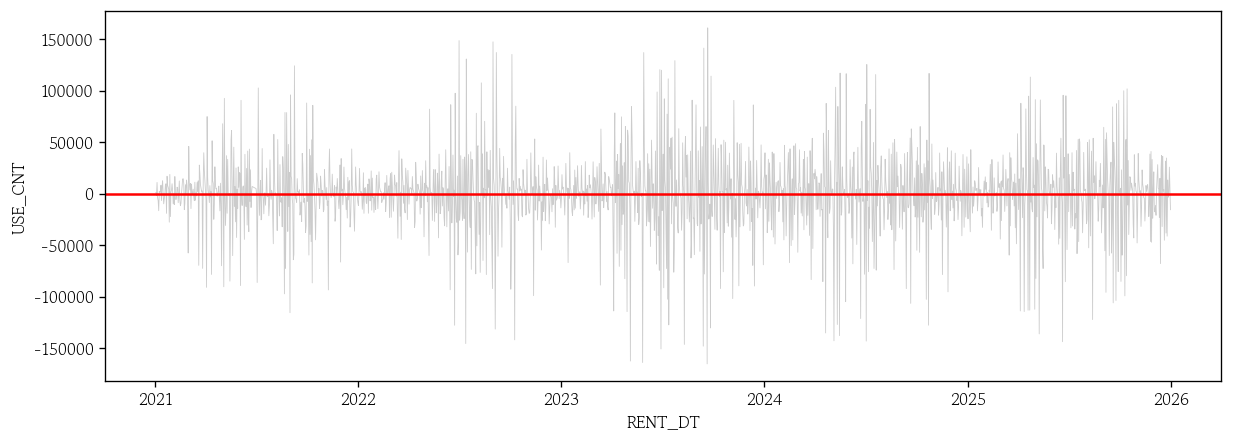

In [16]:
sns.lineplot(x=use_diff_1.index, y=use_diff_1['USE_CNT'], color='0.8', linewidth=0.5)
plt.axhline(y=use_diff_1['USE_CNT'].mean(), color='red')
plt.show()

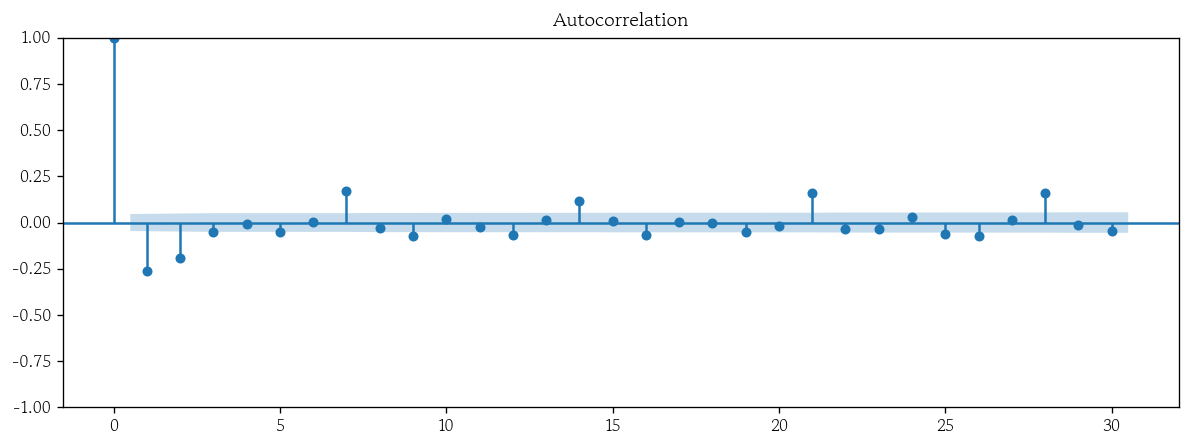

In [17]:
plot_acf(x=use_diff_1, lags=30);

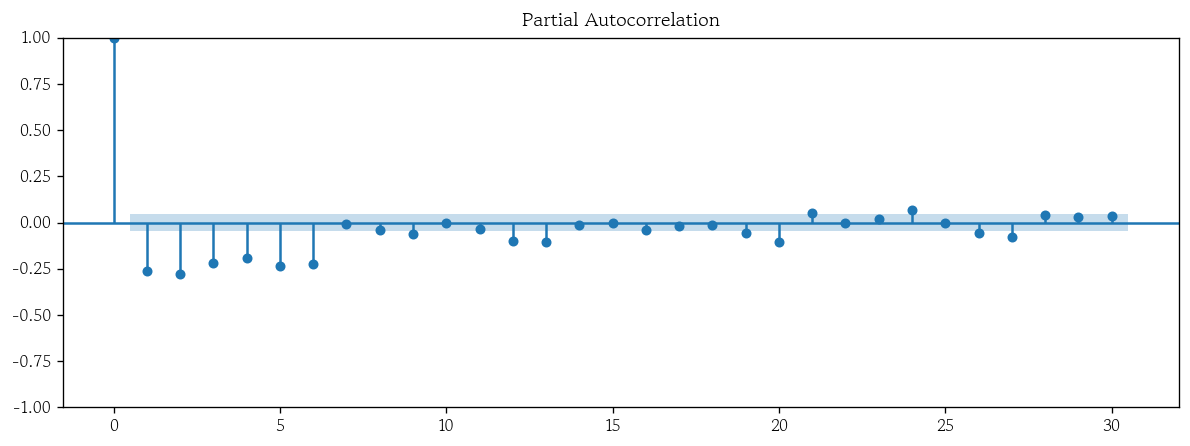

In [18]:
plot_pacf(x=use_diff_1, lags=30);

## ARIMA 모형 생성

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [20]:
arima_model = SARIMAX(
    endog=train,
    order=(0, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

## ARIMA 모형 적합 결과 확인

In [21]:
arima_result = arima_model.fit()

In [22]:
arima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                USE_CNT   No. Observations:                 1461
Model:               SARIMAX(0, 1, 1)   Log Likelihood              -17198.134
Date:                Tue, 24 Mar 2026   AIC                          34400.269
Time:                        17:37:57   BIC                          34410.839
Sample:                    01-01-2021   HQIC                         34404.212
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8088      0.015    -53.799      0.000      -0.838      -0.779
sigma2      1.242e+09   4.93e-13   2.52e+21      0.000    1.24e+09    1.24e+09
===================================================================================
Ljung-Box (L1) (Q):                  87.37   Jarque-Bera (JB):              1078.04
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.23   Skew:                            -1.43
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.47e+37. Standard errors may be unstable.
"""

## ARIMA 모형의 적합도 확인

In [23]:
from statsmodels.stats.diagnostic import acorr_ljungbox

In [24]:
arima_resid = arima_result.resid.dropna() # ARIMA 모형의 잔차를 생성

In [25]:
acorr_ljungbox(x=arima_resid) # 룽 박스 검정을 통해 잔차의 자기상관 여부 확인
#   lb_stat	    lb_pvalue
# 1	87.246095	9.582431e-21
# 2	104.626705	1.908094e-23
# 3	138.091505	9.748678e-30
# 4	155.442875	1.387080e-32
# 5	163.480199	1.793442e-33
# 6	168.112718	1.130396e-33
# 7	201.420868	5.740250e-40
# 8	201.434694	3.185462e-39
# 9	212.201067	9.118374e-41
# 10	214.662629	1.398402e-40

,lb_stat,lb_pvalue
1,87.246095,9.582431e-21
2,104.626705,1.908094e-23
3,138.091505,9.748678e-30
4,155.442875,1.387080e-32
5,163.480199,1.793442e-33
6,168.112718,1.130396e-33
7,201.420868,5.740250e-40
8,201.434694,3.185462e-39
9,212.201067,9.118374e-41
10,214.662629,1.398402e-40


In [26]:
arima_result.aic # ARIMA 모형의 AIC 확인
# 34400.26888872458

34400.26888872458

## ARIMA 모형 잔차의 자기상관 플롯 시각화

In [27]:
from statsmodels.graphics.tsaplots import plot_acf

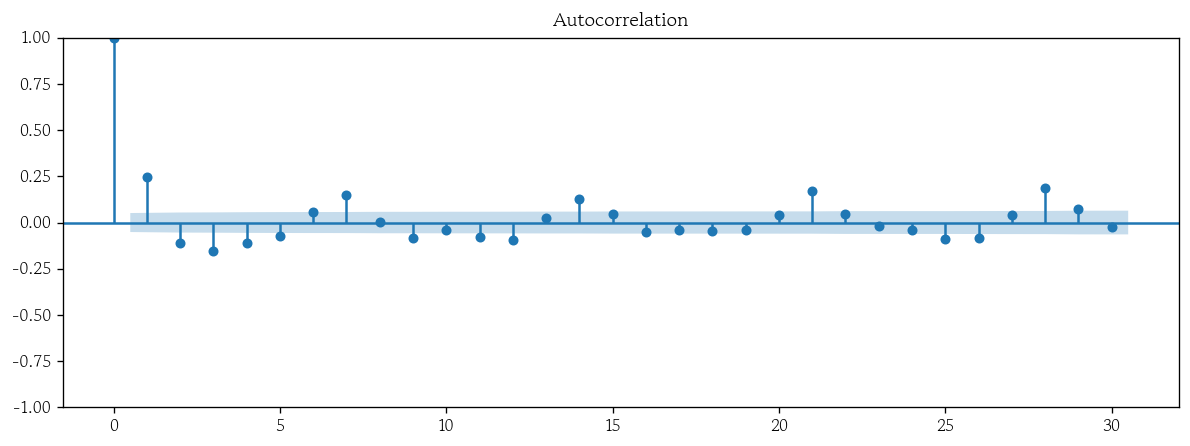

In [28]:
plot_acf(x=arima_resid, lags=30);

## ARIMA 모형의 장기 예측값 생성

In [29]:
n_test = len(test) # 시험셋 크기 설정
arima_pred = arima_result.get_forecast(steps=n_test) # 시험셋 크기만큼 ARIMA 모형의 예측값 생성
arima_pred_avg = arima_pred.predicted_mean # ARIMA 모형의 예측값 평균 생성

## ARIMA 모형의 장기 예측값 시각화

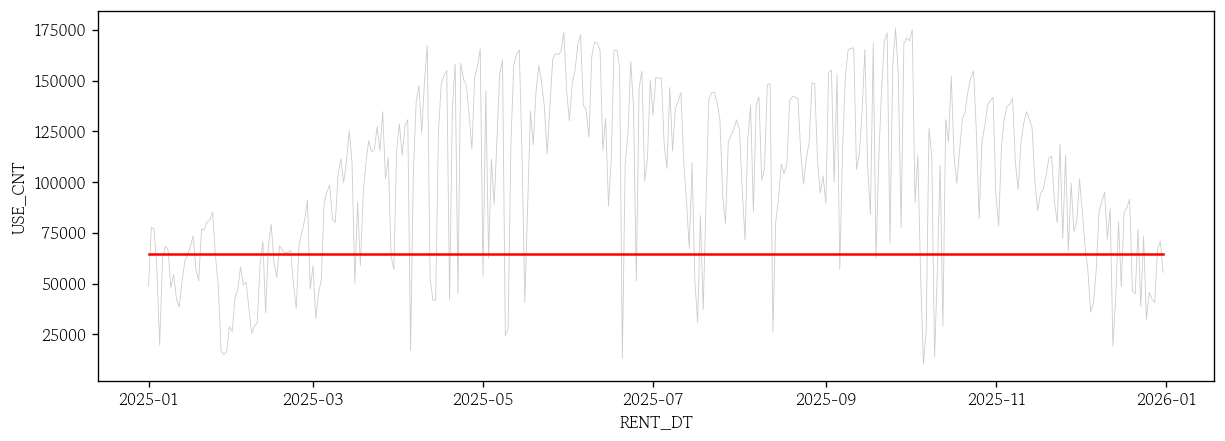

In [30]:
sns.lineplot(x=test.index, y=test['USE_CNT'], color='0.8', linewidth=0.5)
sns.lineplot(x=test.index, y=arima_pred_avg, color='red')
plt.show()

## 1-step Rolling 예측 함수 생성

In [81]:
def rolling_1step(model, test, exog=None):
    preds = pd.Series() # ARIMA 모형 예측값을 저장할 빈 시리즈 생성
    for t in test.index: # test 매개변수의 인덱스를 바꿔가면서 반복문 실행
        if exog is None: # 외생변수가 없는 모형으로 1-step Rolling 예측 실행
            y_hat = model.forecast(1) # 다음 시점 예측값 생성
            model = model.append(endog=test.loc[[t]], refit=False)
        else: # 외생변수가 있는 모형으로 예측 실행
            y_hat = model.forecast(1, exog=exog.loc[[t]])
            model = model.append(endog=test.loc[[t]], exog=exog.loc[[t]], refit=False)
        preds = pd.concat(objs=[preds, y_hat]) # preds에 y_hat 추가
    return preds

## ARIMA 모형의 단기 예측값 시각화

In [32]:
arima_roll = rolling_1step(model=arima_result, test=test) # ARIMA 모형에 대한 예측값 생성

/var/folders/s9/t88_hqjx117_x3pdynjz2nf00000gn/T/ipykernel_80091/3849538346.py:10: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  preds = pd.concat(objs=[preds, y_hat]) # preds에 y_hat 추가


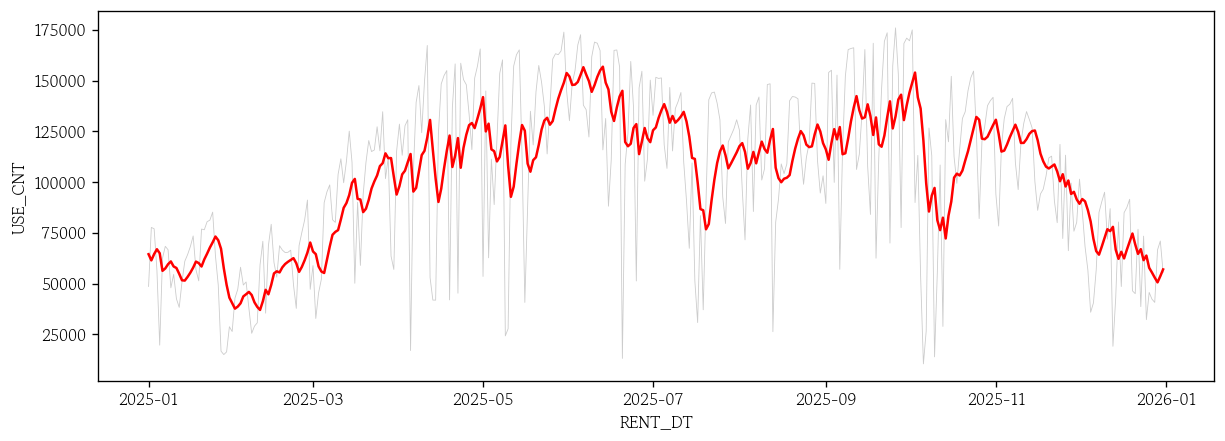

In [33]:
sns.lineplot(x=test.index, y=test['USE_CNT'], color='0.8', linewidth=0.5)
sns.lineplot(x=test.index, y=arima_roll, color='red')
plt.show()

## SARIMA 모형 생성

In [34]:
sarima_model = SARIMAX(
    endog=train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [35]:
sarima_result = sarima_model.fit()

In [36]:
sarima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                           USE_CNT   No. Observations:                 1461
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood              -17092.520
Date:                           Tue, 24 Mar 2026   AIC                          34191.039
Time:                                   17:38:27   BIC                          34206.865
Sample:                               01-01-2021   HQIC                         34196.946
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7716      0.027    -28.561      0.000      -0.825      -0.719
ma.S.L7       -0.9676      0.014    -68.161      0.000      -0.995      -0.940
sigma2      2.006e+09   1.17e-13   1.72e+22      0.000    2.01e+09    2.01e+09
===================================================================================
Ljung-Box (L1) (Q):                  66.48   Jarque-Bera (JB):              1746.77
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.94   Skew:                            -1.69
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.9e+37. Standard errors may be unstable.
"""

## SARIMA 모형의 적합도 확인

In [ ]:
sarima_resid = sarima_result.resid.dropna() # SARIMA 모형의 잔차 생성

In [41]:
acorr_ljungbox(sarima_resid)

,lb_stat,lb_pvalue
1,67.506772,2.099647e-16
2,83.035644,9.311914e-19
3,110.584978,8.211843e-24
4,120.289840,4.631840e-25
5,123.159514,6.719042e-25
6,123.860355,2.516884e-24
7,125.016509,6.897826e-24
8,126.901522,1.240322e-23
9,130.366046,9.971990e-24
10,130.621722,3.488070e-23


## SARIMA 모형 잔차의 자기상관 시각화

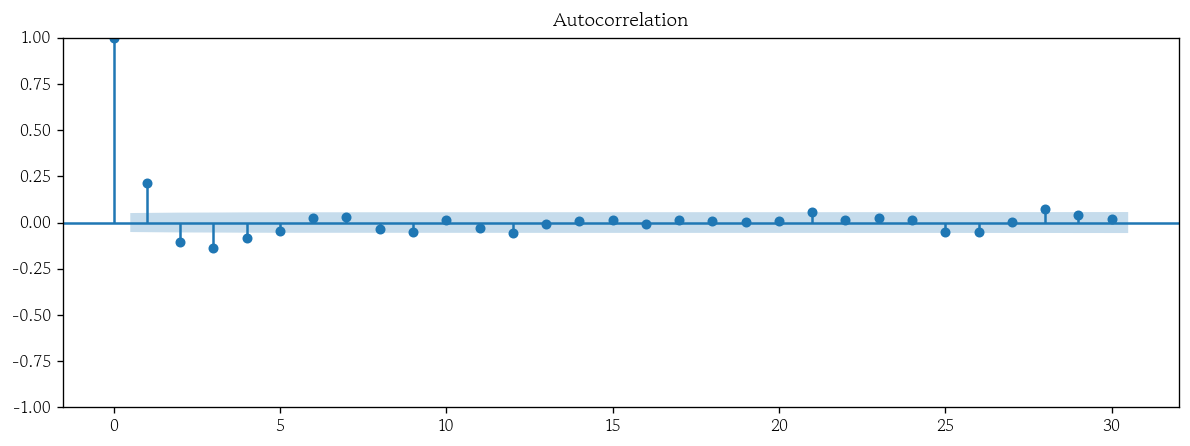

In [40]:
plot_acf(x=sarima_resid, lags=30);

## SARIMA 모형의 장기 예측값 생성

In [43]:
sarima_pred = sarima_result.get_forecast(steps=n_test)

In [44]:
sarima_pred_avg = sarima_pred.predicted_mean

In [45]:
sarima_pred_avg

2025-01-01    71644.198383
2025-01-02    71763.234386
2025-01-03    75431.057320
2025-01-04    48073.729501
2025-01-05    39829.688375
                  ...     
2025-12-27   -45971.550150
2025-12-28   -54215.591276
2025-12-29   -23371.549353
2025-12-30   -27394.607704
2025-12-31   -24245.106359
Freq: D, Name: predicted_mean, Length: 365, dtype: float64

## SARIMA 모형의 장기 예측값 시각화

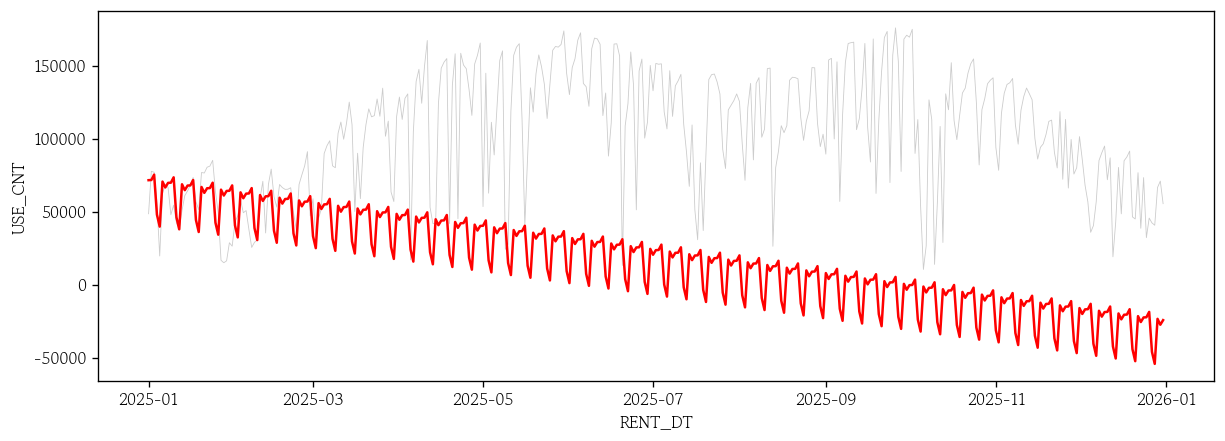

In [46]:
sns.lineplot(x=test.index, y=test['USE_CNT'], color='0.8', linewidth=0.5)
sns.lineplot(x=test.index, y=sarima_pred_avg, color='red')
plt.show()

## SARIMA 모형의 단기 예측값 시각화

In [47]:
sarima_roll = rolling_1step(model=sarima_result, test=test)

/var/folders/s9/t88_hqjx117_x3pdynjz2nf00000gn/T/ipykernel_80091/3849538346.py:10: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  preds = pd.concat(objs=[preds, y_hat]) # preds에 y_hat 추가


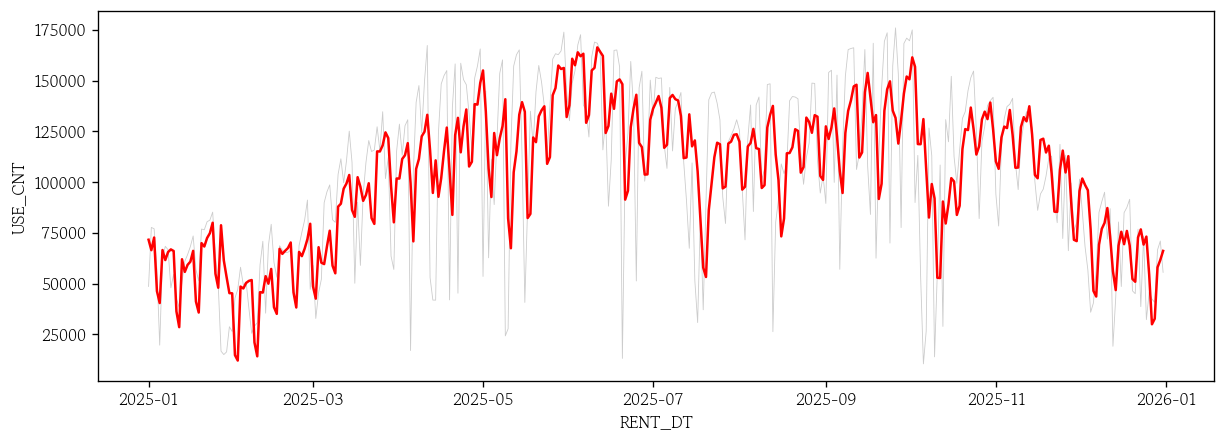

In [48]:
sns.lineplot(x=test.index, y=test['USE_CNT'], color='0.8', linewidth=0.5)
sns.lineplot(x=test.index, y=sarima_roll, color='red')
plt.show()

## 외생변수 데이터셋

In [49]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/data'

In [51]:
[i for i in os.listdir() if 'Weather' in i][0]

'Seoul_Weather_Daily_2021_2025.xlsx'

In [53]:
exog = pd.read_excel('Seoul_Weather_Daily_2021_2025.xlsx')

In [54]:
exog.head()

,date,ta_min,ta_max,ta_avg,rn_sum,ws_avg,hm_avg,ss_sum,ta_range,rn_flag,cold_index,heat_index,disc_index,heavy_rain,chill_wind,good_wther
0,2021-01-01,-9.7,1.4,-4.612500,0.0,2.008333,64.916667,1558,11.1,0,9.7,0.0,30.316453,0,2.008333,0
1,2021-01-02,-8.3,-1.5,-4.729167,0.0,2.650000,39.125000,939,6.8,0,8.3,0.0,35.042716,0,2.650000,0
2,2021-01-03,-9.0,-2.3,-5.629167,0.0,2.079167,44.416667,1066,6.7,0,9.0,0.0,32.913506,0,2.079167,0
3,2021-01-04,-8.3,0.2,-3.770833,0.0,1.612500,48.875000,1173,8.5,0,8.3,0.0,34.431935,0,1.612500,0
4,2021-01-05,-9.5,-2.1,-4.837500,0.0,3.012500,54.250000,1302,7.4,0,9.5,0.0,32.025775,0,3.012500,0


In [55]:
exog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1826 non-null   object 
 1   ta_min      1826 non-null   float64
 2   ta_max      1826 non-null   float64
 3   ta_avg      1826 non-null   float64
 4   rn_sum      1826 non-null   float64
 5   ws_avg      1826 non-null   float64
 6   hm_avg      1826 non-null   float64
 7   ss_sum      1826 non-null   int64  
 8   ta_range    1826 non-null   float64
 9   rn_flag     1826 non-null   int64  
 10  cold_index  1826 non-null   float64
 11  heat_index  1826 non-null   float64
 12  disc_index  1826 non-null   float64
 13  heavy_rain  1826 non-null   int64  
 14  chill_wind  1826 non-null   float64
 15  good_wther  1826 non-null   int64  
dtypes: float64(11), int64(4), object(1)
memory usage: 228.4+ KB


## 외생변수 데이터 전처리

In [56]:
exog.columns

Index(['date', 'ta_min', 'ta_max', 'ta_avg', 'rn_sum', 'ws_avg', 'hm_avg',
       'ss_sum', 'ta_range', 'rn_flag', 'cold_index', 'heat_index',
       'disc_index', 'heavy_rain', 'chill_wind', 'good_wther'],
      dtype='object')

In [ ]:
cols = ['date', 'ta_max', 'rn_sum', 'hm_avg', 'ss_sum'] 

In [58]:
exog = exog[cols]

In [60]:
exog['date'] = pd.to_datetime(exog['date'], errors='coerce')

In [61]:
exog = exog.set_index('date').sort_index()

In [62]:
exog.head()

,ta_max,rn_sum,hm_avg,ss_sum
date,,,,
2021-01-01,1.4,0.0,64.916667,1558
2021-01-02,-1.5,0.0,39.125000,939
2021-01-03,-2.3,0.0,44.416667,1066
2021-01-04,0.2,0.0,48.875000,1173
2021-01-05,-2.1,0.0,54.250000,1302


## 외생변수 데이터셋 분할

In [63]:
std_date = '2025-01-01'

In [64]:
exog_train = exog.loc[:std_date].iloc[:-1]
exog_test = exog.loc[std_date:]

In [65]:
display(exog_train.tail())
display(exog_test.head())

,ta_max,rn_sum,hm_avg,ss_sum
date,,,,
2024-12-27,1.7,0.0,50.541667,1213
2024-12-28,0.9,0.0,48.625000,1167
2024-12-29,5.3,0.0,55.125000,1323
2024-12-30,9.9,0.0,67.541667,1621
2024-12-31,4.8,0.0,46.791667,1123


,ta_max,rn_sum,hm_avg,ss_sum
date,,,,
2025-01-01,8.5,0.0,63.083333,1514
2025-01-02,5.9,0.0,50.291667,1207
2025-01-03,3.1,0.0,50.333333,1208
2025-01-04,5.5,0.0,49.291667,1183
2025-01-05,2.4,6.7,82.333333,1976


In [66]:
exog_train = exog_train.asfreq('D')
exog_test = exog_test.asfreq('D')

In [68]:
exog_train.index

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08',
               '2021-01-09', '2021-01-10',
               ...
               '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27', '2024-12-28', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='date', length=1461, freq='D')

In [69]:
exog_test.index

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', name='date', length=365, freq='D')

## SARIMAX 모형 생성

In [70]:
sarimax_model = SARIMAX(
    endog=train,
    exog=exog_train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [71]:
sarimax_result = sarimax_model.fit()

In [72]:
sarimax_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                           USE_CNT   No. Observations:                 1461
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood              -16393.095
Date:                           Tue, 24 Mar 2026   AIC                          32800.191
Time:                                   18:01:56   BIC                          32837.117
Sample:                               01-01-2021   HQIC                         32813.973
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ta_max      2984.5905    287.078     10.396      0.000    2421.928    3547.253
rn_sum     -1095.4567     40.110    -27.311      0.000   -1174.072   -1016.842
hm_avg        -1.1491      0.136     -8.460      0.000      -1.415      -0.883
ss_sum       -27.5780      3.260     -8.460      0.000     -33.967     -21.189
ma.L1         -0.7387      0.026    -28.275      0.000      -0.790      -0.687
ma.S.L7       -0.8969      0.020    -44.592      0.000      -0.936      -0.857
sigma2      7.357e+08      0.000   4.71e+12      0.000    7.36e+08    7.36e+08
===================================================================================
Ljung-Box (L1) (Q):                  25.11   Jarque-Bera (JB):               699.91
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.84   Skew:                            -0.72
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.09
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.53e+27. Standard errors may be unstable.
"""

## SARIMAX 모형의 적합도 확인

In [73]:
sarimax_resid = sarimax_result.resid.dropna()

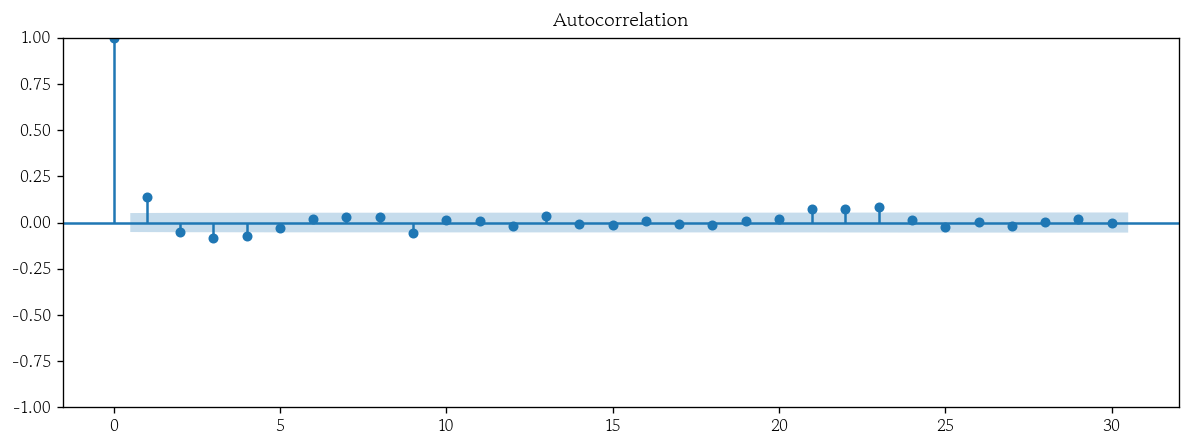

In [74]:
plot_acf(x=sarimax_resid, lags=30);

## SARIMAX 모형의 장기 예측값 생성

In [75]:
sarimax_pred = sarimax_result.get_forecast(steps=n_test, exog=exog_test)

In [76]:
sarimax_pred_avg = sarimax_pred.predicted_mean

## SARIMAX 모형의 장기 예측값 시각화

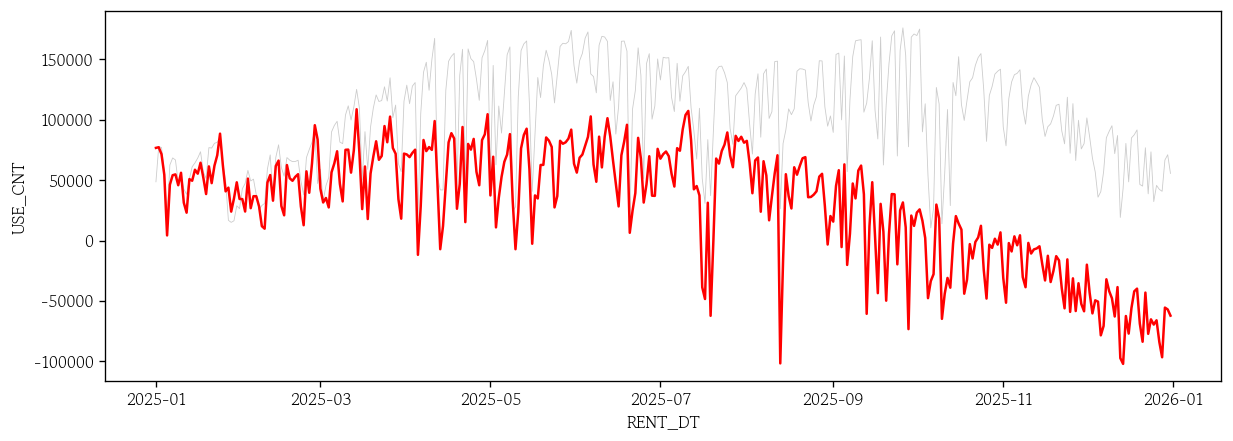

In [77]:
sns.lineplot(x=test.index, y=test['USE_CNT'], color='0.8', linewidth=0.5)
sns.lineplot(x=test.index, y=sarimax_pred_avg, color='red')
plt.show()

## SARIMAX 모형 단기 예측값 시각화

In [82]:
sarimax_roll = rolling_1step(model=sarimax_result, test=test, exog=exog_test)

/var/folders/s9/t88_hqjx117_x3pdynjz2nf00000gn/T/ipykernel_80091/3021803403.py:10: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  preds = pd.concat(objs=[preds, y_hat]) # preds에 y_hat 추가


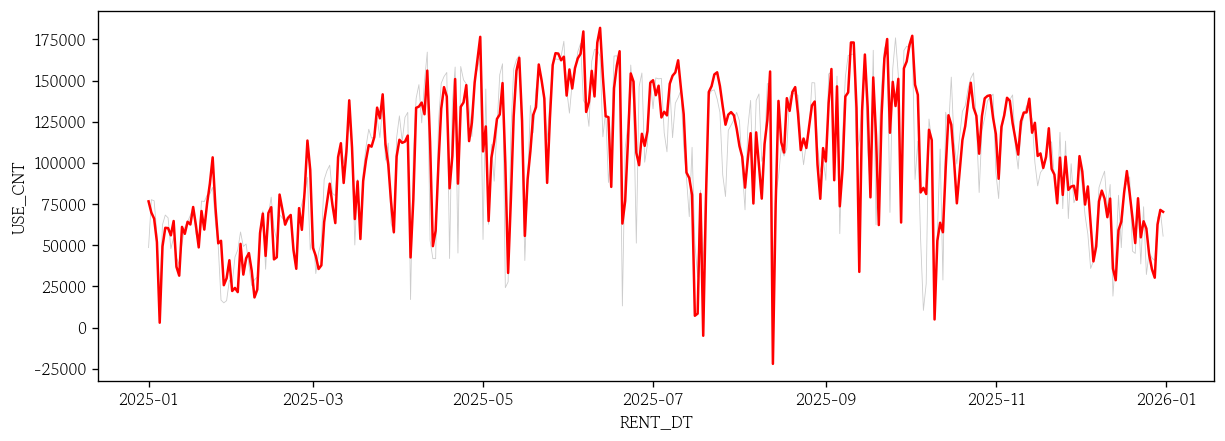

In [83]:
sns.lineplot(x=test.index, y=test['USE_CNT'], color='0.8', linewidth=0.5)
sns.lineplot(x=test.index, y=sarimax_roll, color='red')
plt.show()

## ARIMA 계열 모형의 예측 성능 비교

In [84]:
hds.stat.regmetrics(y_true=test['USE_CNT'], y_pred=sarima_roll).loc[[2, 6], ['metric', 'score']].reset_index(drop=True)

,metric,score
0,RMSE,30906.828783
1,MAPE,0.406061


In [85]:
hds.stat.regmetrics(y_true=test['USE_CNT'], y_pred=sarimax_roll).loc[[2, 6], ['metric', 'score']].reset_index(drop=True)

,metric,score
0,RMSE,19540.326177
1,MAPE,0.226286


## 외부 파일로 저장

In [86]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/data'

In [87]:
objs = {
    'exog': exog,
    'exog_test': exog_test,
    'exog_train': exog_train
}

In [88]:
pd.to_pickle(obj=objs, filepath_or_buffer='Seoul_Weather_Prep.pkl')